In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取BTC日线数据
df = pd.read_csv("../04_crypto/btc_daily.csv", index_col=0, parse_dates=True)
close = df["close"]
volume = df["volume"]
high = df["high"]
low = df["low"]

print(f"数据维度：{df.shape}")
print(f"时间范围：{df.index[0].date()} 到 {df.index[-1].date()}")

数据维度：(1183, 5)
时间范围：2023-01-01 到 2026-03-28


In [2]:
# 构建特征矩阵
features = pd.DataFrame(index=close.index)

# 动量特征
features["mom_5"] = close / close.shift(5) - 1
features["mom_10"] = close / close.shift(10) - 1
features["mom_20"] = close / close.shift(20) - 1
features["mom_60"] = close / close.shift(60) - 1

# MACD特征
ema12 = close.ewm(span=12).mean()
ema26 = close.ewm(span=26).mean()
macd = ema12 - ema26
signal = macd.ewm(span=9).mean()
features["macd"] = macd
features["macd_signal"] = macd - signal

# 波动率特征
features["vol_10"] = close.pct_change().rolling(10).std()
features["vol_20"] = close.pct_change().rolling(20).std()

# 成交量特征
features["volume_ratio"] = volume / volume.rolling(20).mean()
features["price_volume"] = close.pct_change() * volume

# RSI
delta = close.diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
features["rsi"] = 100 - 100 / (1 + rs)

# 布林带位置
ma20 = close.rolling(20).mean()
std20 = close.rolling(20).std()
features["bb_position"] = (close - ma20) / (2 * std20)

# 恐贪指数
fng = pd.read_csv("../04_crypto/btc_fng.csv", index_col=0, parse_dates=True)
fng.index = fng.index.tz_localize(None)
features["fng"] = fng["value"].reindex(close.index, method="ffill")

print(f"特征维度：{features.shape}")
print(features.tail())

特征维度：(1183, 13)
               mom_5    mom_10    mom_20    mom_60        macd  macd_signal  \
date                                                                          
2026-03-24  0.009064 -0.009212 -0.029181 -0.212598   50.023484   -38.272744   
2026-03-25  0.011617 -0.020217  0.006355 -0.200529  123.615802    28.255660   
2026-03-26 -0.001362 -0.080876  0.010425 -0.205841  -20.179571   -92.431770   
2026-03-27 -0.021459 -0.101487 -0.012772 -0.248382 -325.921477  -318.538941   
2026-03-28 -0.058884 -0.063548  0.011397 -0.252380 -536.125860  -422.994659   

              vol_10    vol_20  volume_ratio  price_volume        rsi  \
date                                                                    
2026-03-24  0.025747  0.023574      0.951395    -33.187041  51.838313   
2026-03-25  0.024855  0.023050      0.852763     65.487139  53.342245   
2026-03-26  0.024386  0.022712      0.976190   -231.366537  45.586324   
2026-03-27  0.025845  0.023943      1.376397   -339.270694  39.34

In [3]:
# 定义标签：未来5天涨超1%为1（买入），否则为0（不买）
future_ret = close.shift(-5) / close - 1
labels = (future_ret > 0.01).astype(int)

# 合并特征和标签，删除NaN
data = features.copy()
data["label"] = labels
data = data.dropna()

print(f"样本总数：{len(data)}")
print(f"正样本（涨）：{data['label'].sum()}  {data['label'].mean():.2%}")
print(f"负样本（不涨）：{(data['label']==0).sum()}  {(data['label']==0).mean():.2%}")

样本总数：1123
正样本（涨）：462  41.14%
负样本（不涨）：661  58.86%


In [4]:
# 时间序列分割：前80%训练，后20%测试
# 注意：不能随机分割，必须按时间顺序，否则会有未来函数
split = int(len(data) * 0.8)
train = data.iloc[:split]
test = data.iloc[split:]

X_train = train.drop(columns=["label"])
y_train = train["label"]
X_test = test.drop(columns=["label"])
y_test = test["label"]

print(f"训练集：{len(train)}条，{train.index[0].date()} 到 {train.index[-1].date()}")
print(f"测试集：{len(test)}条，{test.index[0].date()} 到 {test.index[-1].date()}")
print(f"训练集正样本比例：{y_train.mean():.2%}")
print(f"测试集正样本比例：{y_test.mean():.2%}")

# 训练XGBoost模型
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# 在测试集上预测
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"\n测试集准确率：{accuracy_score(y_test, y_pred):.4f}")
print(f"\n详细报告：")
print(classification_report(y_test, y_pred))

训练集：898条，2023-03-02 到 2025-08-15
测试集：225条，2025-08-16 到 2026-03-28
训练集正样本比例：43.54%
测试集正样本比例：31.56%

测试集准确率：0.5111

详细报告：
              precision    recall  f1-score   support

           0       0.77      0.41      0.53       154
           1       0.36      0.73      0.49        71

    accuracy                           0.51       225
   macro avg       0.57      0.57      0.51       225
weighted avg       0.64      0.51      0.52       225



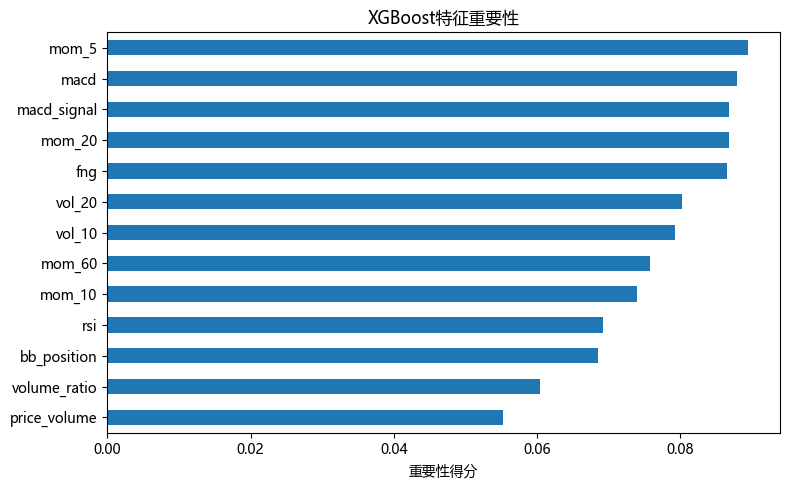

mom_5           0.089458
macd            0.087973
macd_signal     0.086834
mom_20          0.086750
fng             0.086508
vol_20          0.080221
vol_10          0.079217
mom_60          0.075817
mom_10          0.073938
rsi             0.069155
bb_position     0.068544
volume_ratio    0.060400
price_volume    0.055185
dtype: float32


In [5]:
# 特征重要性
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.title("XGBoost特征重要性")
plt.xlabel("重要性得分")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False))

ML策略 累计收益：-23.74%
ML策略 Sharpe：-0.8649
ML策略 最大回撤：-28.39%
买入持有 累计收益：-43.16%
持仓天数比例：55.80%


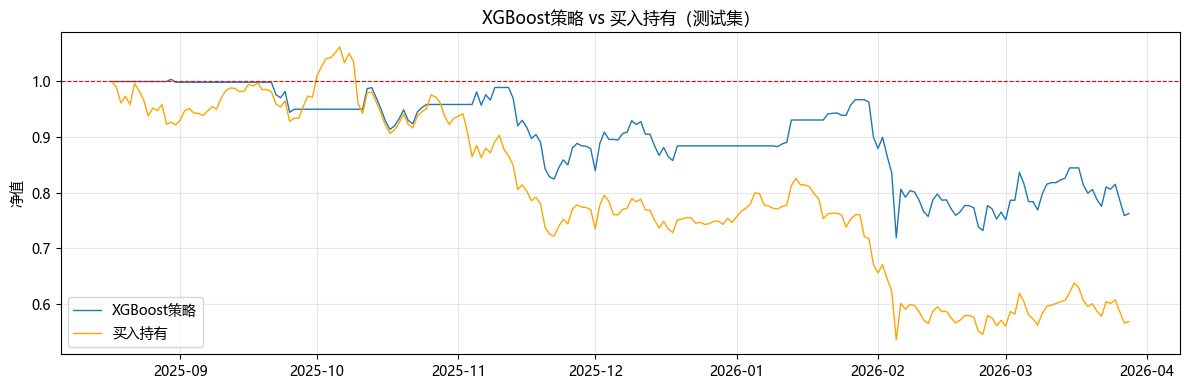

In [6]:
# 用模型预测概率做交易信号
# 概率>0.55才买入，不是简单的0.5阈值
threshold = 0.55
signal_ml = (y_prob > threshold).astype(int)

# 对应的收益
test_close = close[X_test.index]
test_ret = test_close.pct_change().dropna()
sig = pd.Series(signal_ml, index=X_test.index).shift(1).dropna()
c = test_ret.index.intersection(sig.index)
strat_ret = test_ret[c] * sig[c]

pv_ml = (1 + strat_ret).cumprod()
bh = (1 + test_ret[c]).cumprod()

total_ml = pv_ml.iloc[-1] - 1
sharpe_ml = strat_ret.mean() / strat_ret.std() * np.sqrt(365) if strat_ret.std() > 0 else 0
dd_ml = ((pv_ml - pv_ml.cummax()) / pv_ml.cummax()).min()

print(f"ML策略 累计收益：{total_ml:.2%}")
print(f"ML策略 Sharpe：{sharpe_ml:.4f}")
print(f"ML策略 最大回撤：{dd_ml:.2%}")
print(f"买入持有 累计收益：{bh.iloc[-1]-1:.2%}")
print(f"持仓天数比例：{sig.mean():.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_ml.index, pv_ml, linewidth=1, label="XGBoost策略")
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("XGBoost策略 vs 买入持有（测试集）")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# 改进标签：未来10天涨跌方向
future_ret2 = close.shift(-10) / close - 1
labels2 = (future_ret2 > 0).astype(int)

data2 = features.copy()
data2["label"] = labels2
data2 = data2.dropna()

split = int(len(data2) * 0.8)
train2 = data2.iloc[:split]
test2 = data2.iloc[split:]

X_train2 = train2.drop(columns=["label"])
y_train2 = train2["label"]
X_test2 = test2.drop(columns=["label"])
y_test2 = test2["label"]

model2 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)
y_prob2 = model2.predict_proba(X_test2)[:, 1]

print(f"改进版准确率：{accuracy_score(y_test2, y_pred2):.4f}")
print(classification_report(y_test2, y_pred2))

改进版准确率：0.4533
              precision    recall  f1-score   support

           0       0.64      0.30      0.41       142
           1       0.37      0.71      0.49        83

    accuracy                           0.45       225
   macro avg       0.51      0.51      0.45       225
weighted avg       0.54      0.45      0.44       225



In [8]:
# 预测未来10天是否是高波动期
future_vol = close.pct_change().rolling(10).std().shift(-10)
vol_median = future_vol.median()
labels3 = (future_vol > vol_median).astype(int)  # 1=高波动，0=低波动

data3 = features.copy()
data3["label"] = labels3
data3 = data3.dropna()

split = int(len(data3) * 0.8)
train3 = data3.iloc[:split]
test3 = data3.iloc[split:]

X_train3 = train3.drop(columns=["label"])
y_train3 = train3["label"]
X_test3 = test3.drop(columns=["label"])
y_test3 = test3["label"]

model3 = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model3.fit(X_train3, y_train3)
y_pred3 = model3.predict(X_test3)
y_prob3 = model3.predict_proba(X_test3)[:, 1]

print(f"波动率预测准确率：{accuracy_score(y_test3, y_pred3):.4f}")
print(classification_report(y_test3, y_pred3))

波动率预测准确率：0.4533
              precision    recall  f1-score   support

           0       0.55      0.30      0.39       130
           1       0.41      0.66      0.51        95

    accuracy                           0.45       225
   macro avg       0.48      0.48      0.45       225
weighted avg       0.49      0.45      0.44       225



In [9]:
# 用小时线数据重新构建特征
df_1h = pd.read_csv("../04_crypto/btc_1h.csv", index_col=0, parse_dates=True)
close_1h = df_1h["close"]
volume_1h = df_1h["volume"]

features_1h = pd.DataFrame(index=close_1h.index)

# 动量特征
features_1h["mom_6"] = close_1h / close_1h.shift(6) - 1
features_1h["mom_24"] = close_1h / close_1h.shift(24) - 1
features_1h["mom_72"] = close_1h / close_1h.shift(72) - 1
features_1h["mom_168"] = close_1h / close_1h.shift(168) - 1  # 7天

# MACD（小时线参数）
ema_f = close_1h.ewm(span=50).mean()
ema_s = close_1h.ewm(span=150).mean()
macd_1h = ema_f - ema_s
signal_1h = macd_1h.ewm(span=30).mean()
features_1h["macd"] = macd_1h
features_1h["macd_signal"] = macd_1h - signal_1h

# 波动率
features_1h["vol_24"] = close_1h.pct_change().rolling(24).std()
features_1h["vol_72"] = close_1h.pct_change().rolling(72).std()

# 成交量
features_1h["volume_ratio"] = volume_1h / volume_1h.rolling(24).mean()

# RSI
delta = close_1h.diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
features_1h["rsi"] = 100 - 100 / (1 + gain/loss)

# 布林带
ma24 = close_1h.rolling(24).mean()
std24 = close_1h.rolling(24).std()
features_1h["bb_position"] = (close_1h - ma24) / (2 * std24)

# 标签：未来24小时涨跌方向
future_ret_1h = close_1h.shift(-24) / close_1h - 1
labels_1h = (future_ret_1h > 0).astype(int)

data_1h = features_1h.copy()
data_1h["label"] = labels_1h
data_1h = data_1h.dropna()

print(f"样本总数：{len(data_1h)}")
print(f"正样本比例：{data_1h['label'].mean():.2%}")

样本总数：28217
正样本比例：51.93%


In [10]:
# 时间序列分割：前80%训练，后20%测试
split = int(len(data_1h) * 0.8)
train_1h = data_1h.iloc[:split]
test_1h = data_1h.iloc[split:]

X_train_1h = train_1h.drop(columns=["label"])
y_train_1h = train_1h["label"]
X_test_1h = test_1h.drop(columns=["label"])
y_test_1h = test_1h["label"]

print(f"训练集：{len(train_1h)}条，{train_1h.index[0]} 到 {train_1h.index[-1]}")
print(f"测试集：{len(test_1h)}条，{test_1h.index[0]} 到 {test_1h.index[-1]}")

# 训练XGBoost
model_1h = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model_1h.fit(X_train_1h, y_train_1h)
y_pred_1h = model_1h.predict(X_test_1h)
y_prob_1h = model_1h.predict_proba(X_test_1h)[:, 1]

print(f"\n测试集准确率：{accuracy_score(y_test_1h, y_pred_1h):.4f}")
print(classification_report(y_test_1h, y_pred_1h))

训练集：22573条，2023-01-08 00:00:00 到 2025-08-05 12:00:00
测试集：5644条，2025-08-05 13:00:00 到 2026-03-28 16:00:00

测试集准确率：0.4660
              precision    recall  f1-score   support

           0       0.48      0.32      0.39      2925
           1       0.46      0.62      0.53      2719

    accuracy                           0.47      5644
   macro avg       0.47      0.47      0.46      5644
weighted avg       0.47      0.47      0.45      5644



In [11]:
# 重新定义标签：未来24小时波动率是否高于历史中位数
future_vol_1h = close_1h.pct_change().rolling(24).std().shift(-24)
vol_median_1h = future_vol_1h.median()
labels_vol = (future_vol_1h > vol_median_1h).astype(int)

print(f"波动率中位数：{vol_median_1h:.4f}")
print(f"高波动比例：{labels_vol.mean():.2%}")

data_vol = features_1h.copy()
data_vol["label"] = labels_vol
data_vol = data_vol.dropna()

split = int(len(data_vol) * 0.8)
train_vol = data_vol.iloc[:split]
test_vol = data_vol.iloc[split:]

X_train_vol = train_vol.drop(columns=["label"])
y_train_vol = train_vol["label"]
X_test_vol = test_vol.drop(columns=["label"])
y_test_vol = test_vol["label"]

model_vol = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model_vol.fit(X_train_vol, y_train_vol)
y_pred_vol = model_vol.predict(X_test_vol)
y_prob_vol = model_vol.predict_proba(X_test_vol)[:, 1]

print(f"\n波动率预测准确率：{accuracy_score(y_test_vol, y_pred_vol):.4f}")
print(classification_report(y_test_vol, y_pred_vol))

波动率中位数：0.0040
高波动比例：49.96%

波动率预测准确率：0.6713
              precision    recall  f1-score   support

           0       0.67      0.66      0.67      2796
           1       0.67      0.68      0.68      2848

    accuracy                           0.67      5644
   macro avg       0.67      0.67      0.67      5644
weighted avg       0.67      0.67      0.67      5644



满仓比例：29.15%
半仓比例：35.01%
空仓比例：35.84%

ML波动率策略 累计收益：-12.27%
ML波动率策略 Sharpe：-0.9416
ML波动率策略 最大回撤：-25.71%
买入持有 累计收益：-41.38%


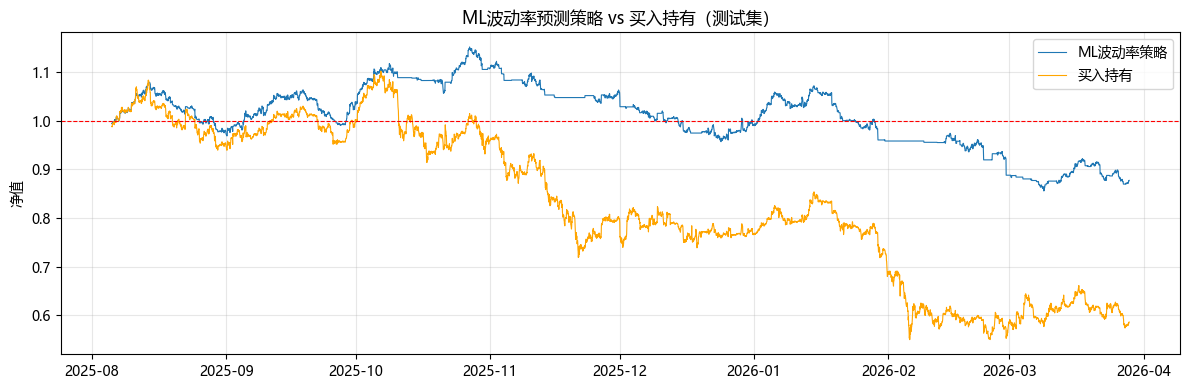

In [12]:
# 用波动率预测做仓位管理
# 预测低波动期（prob<0.4）满仓，高波动期（prob>0.6）空仓，中间半仓
test_close_1h = close_1h[X_test_vol.index]
ret_1h_test = test_close_1h.pct_change().dropna()

# 生成仓位信号
vol_signal = pd.Series(index=X_test_vol.index, dtype=float)
vol_signal[y_prob_vol < 0.4] = 1.0   # 低波动，满仓
vol_signal[(y_prob_vol >= 0.4) & (y_prob_vol <= 0.6)] = 0.5  # 中等，半仓
vol_signal[y_prob_vol > 0.6] = 0.0   # 高波动，空仓

print(f"满仓比例：{(vol_signal==1.0).mean():.2%}")
print(f"半仓比例：{(vol_signal==0.5).mean():.2%}")
print(f"空仓比例：{(vol_signal==0.0).mean():.2%}")

# 回测
sig = vol_signal.shift(1).dropna()
c = ret_1h_test.index.intersection(sig.index)
strat_ret = ret_1h_test[c] * sig[c]

pv_vol_ml = (1 + strat_ret).cumprod()
bh = (1 + ret_1h_test[c]).cumprod()

total = pv_vol_ml.iloc[-1] - 1
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(8760)
dd = ((pv_vol_ml - pv_vol_ml.cummax()) / pv_vol_ml.cummax()).min()

print(f"\nML波动率策略 累计收益：{total:.2%}")
print(f"ML波动率策略 Sharpe：{sharpe:.4f}")
print(f"ML波动率策略 最大回撤：{dd:.2%}")
print(f"买入持有 累计收益：{bh.iloc[-1]-1:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_vol_ml.index, pv_vol_ml, linewidth=0.8, label="ML波动率策略")
plt.plot(bh.index, bh, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("ML波动率预测策略 vs 买入持有（测试集）")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# 滚动预测：每次用过去数据训练，预测下一段
# 分成10段，每段用前面所有数据训练，预测这一段

all_probs = pd.Series(dtype=float, index=data_vol.index)
n_splits = 10
split_size = len(data_vol) // n_splits

for i in range(1, n_splits):
    train_end = i * split_size
    test_start = train_end
    test_end = min((i+1) * split_size, len(data_vol))
    
    tr = data_vol.iloc[:train_end]
    te = data_vol.iloc[test_start:test_end]
    
    Xtr = tr.drop(columns=["label"])
    ytr = tr["label"]
    Xte = te.drop(columns=["label"])
    
    if len(tr) < 500:
        continue
    
    m = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric="logloss"
    )
    m.fit(Xtr, ytr)
    probs = m.predict_proba(Xte)[:, 1]
    all_probs.iloc[test_start:test_end] = probs
    print(f"第{i}段完成：{te.index[0].date()} 到 {te.index[-1].date()}")

all_probs = all_probs.dropna()
print(f"\n预测覆盖：{all_probs.index[0].date()} 到 {all_probs.index[-1].date()}")
print(f"总样本数：{len(all_probs)}")

第1段完成：2023-05-05 到 2023-08-31
第2段完成：2023-08-31 到 2023-12-26
第3段完成：2023-12-26 到 2024-04-22
第4段完成：2024-04-22 到 2024-08-17
第5段完成：2024-08-17 到 2024-12-13
第6段完成：2024-12-13 到 2025-04-09
第7段完成：2025-04-09 到 2025-08-05
第8段完成：2025-08-05 到 2025-11-30
第9段完成：2025-11-30 到 2026-03-28

预测覆盖：2023-05-05 到 2026-03-28
总样本数：25389


满仓比例：28.45%
半仓比例：34.64%
空仓比例：36.91%

ML波动率策略 累计收益：92.59%
ML波动率策略 Sharpe：1.1667
ML波动率策略 最大回撤：-21.59%
买入持有 累计收益：127.24%


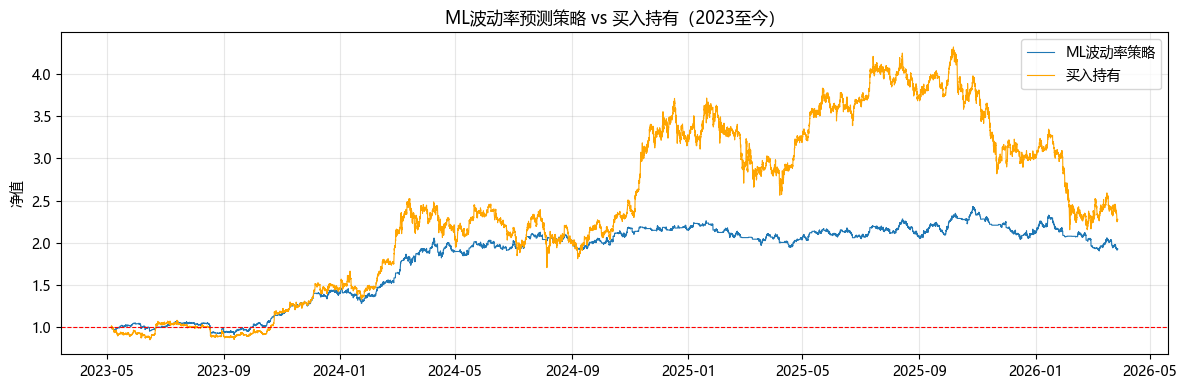

In [14]:
# 用滚动预测结果做回测
close_aligned = close_1h[all_probs.index]
ret_aligned = close_aligned.pct_change().dropna()

# 生成仓位信号
vol_signal_full = pd.Series(index=all_probs.index, dtype=float)
vol_signal_full[all_probs < 0.4] = 1.0
vol_signal_full[(all_probs >= 0.4) & (all_probs <= 0.6)] = 0.5
vol_signal_full[all_probs > 0.6] = 0.0

print(f"满仓比例：{(vol_signal_full==1.0).mean():.2%}")
print(f"半仓比例：{(vol_signal_full==0.5).mean():.2%}")
print(f"空仓比例：{(vol_signal_full==0.0).mean():.2%}")

sig = vol_signal_full.shift(1).dropna()
c = ret_aligned.index.intersection(sig.index)
strat_ret = ret_aligned[c] * sig[c]

pv_full = (1 + strat_ret).cumprod()
bh_full = (1 + ret_aligned[c]).cumprod()

total = pv_full.iloc[-1] - 1
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(8760)
dd = ((pv_full - pv_full.cummax()) / pv_full.cummax()).min()

print(f"\nML波动率策略 累计收益：{total:.2%}")
print(f"ML波动率策略 Sharpe：{sharpe:.4f}")
print(f"ML波动率策略 最大回撤：{dd:.2%}")
print(f"买入持有 累计收益：{bh_full.iloc[-1]-1:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_full.index, pv_full, linewidth=0.8, label="ML波动率策略")
plt.plot(bh_full.index, bh_full, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("ML波动率预测策略 vs 买入持有（2023至今）")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# 改进：预测未来24小时是否下跌+高波动（真正的风险）
future_ret_1h_raw = close_1h.shift(-24) / close_1h - 1
future_vol_1h_raw = close_1h.pct_change().rolling(24).std().shift(-24)

# 高风险 = 下跌 且 高波动
high_risk = ((future_ret_1h_raw < 0) & (future_vol_1h_raw > vol_median_1h)).astype(int)

print(f"高风险比例：{high_risk.mean():.2%}")
print(f"低风险比例：{(high_risk==0).mean():.2%}")

data_risk = features_1h.copy()
data_risk["label"] = high_risk
data_risk = data_risk.dropna()

# 用滚动预测
all_probs2 = pd.Series(dtype=float, index=data_risk.index)
split_size2 = len(data_risk) // 10

for i in range(1, 10):
    train_end = i * split_size2
    test_start = train_end
    test_end = min((i+1) * split_size2, len(data_risk))
    
    tr = data_risk.iloc[:train_end]
    te = data_risk.iloc[test_start:test_end]
    
    if len(tr) < 500:
        continue
    
    m = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric="logloss"
    )
    m.fit(tr.drop(columns=["label"]), tr["label"])
    probs = m.predict_proba(te.drop(columns=["label"]))[:, 1]
    all_probs2.iloc[test_start:test_end] = probs

all_probs2 = all_probs2.dropna()

# 高风险期空仓，低风险期满仓
vol_signal2 = pd.Series(1.0, index=all_probs2.index)
vol_signal2[all_probs2 > 0.6] = 0.0  # 预测高风险，空仓
vol_signal2[(all_probs2 > 0.4) & (all_probs2 <= 0.6)] = 0.5  # 不确定，半仓

print(f"满仓：{(vol_signal2==1.0).mean():.2%}")
print(f"半仓：{(vol_signal2==0.5).mean():.2%}")
print(f"空仓：{(vol_signal2==0.0).mean():.2%}")

高风险比例：24.31%
低风险比例：75.69%
满仓：87.97%
半仓：10.70%
空仓：1.33%


ML风险策略 累计收益：200.97%
ML风险策略 Sharpe：1.0980
ML风险策略 最大回撤：-48.54%
买入持有 累计收益：127.24%


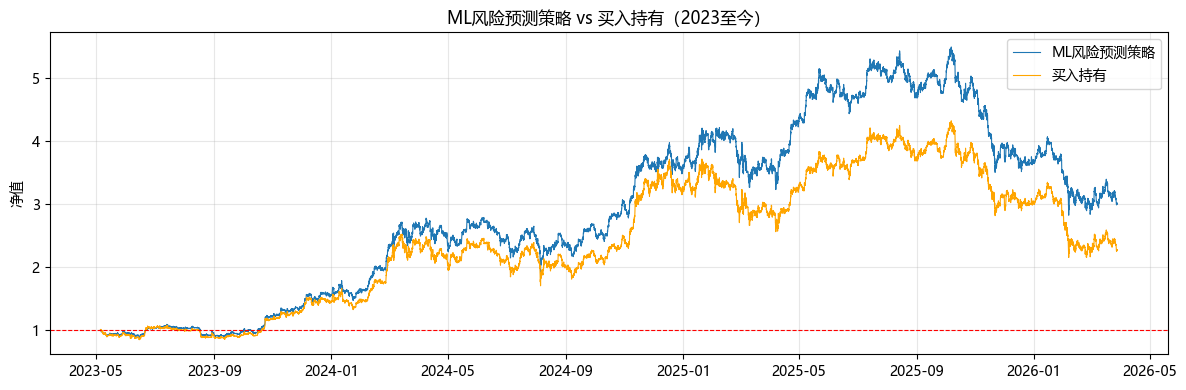

In [16]:
close_aligned2 = close_1h[all_probs2.index]
ret_aligned2 = close_aligned2.pct_change().dropna()

sig2 = vol_signal2.shift(1).dropna()
c2 = ret_aligned2.index.intersection(sig2.index)
strat_ret2 = ret_aligned2[c2] * sig2[c2]

pv_risk = (1 + strat_ret2).cumprod()
bh_risk = (1 + ret_aligned2[c2]).cumprod()

total2 = pv_risk.iloc[-1] - 1
sharpe2 = strat_ret2.mean() / strat_ret2.std() * np.sqrt(8760)
dd2 = ((pv_risk - pv_risk.cummax()) / pv_risk.cummax()).min()

print(f"ML风险策略 累计收益：{total2:.2%}")
print(f"ML风险策略 Sharpe：{sharpe2:.4f}")
print(f"ML风险策略 最大回撤：{dd2:.2%}")
print(f"买入持有 累计收益：{bh_risk.iloc[-1]-1:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_risk.index, pv_risk, linewidth=0.8, label="ML风险预测策略")
plt.plot(bh_risk.index, bh_risk, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("ML风险预测策略 vs 买入持有（2023至今）")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MACD+ML组合 累计收益：178.72%
MACD+ML组合 Sharpe：1.3436
MACD+ML组合 最大回撤：-26.60%


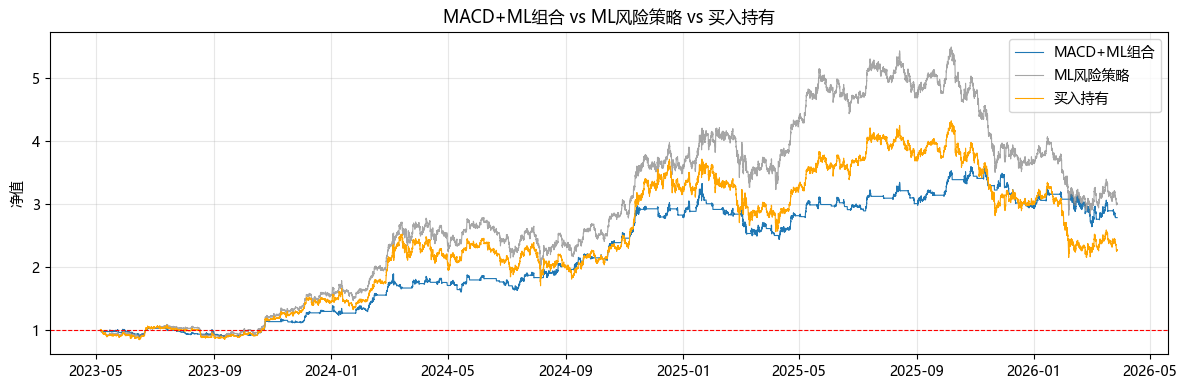

In [17]:
# MACD信号 + ML风险过滤
ema_f = close_1h.ewm(span=150).mean()
ema_s = close_1h.ewm(span=400).mean()
m_line = ema_f - ema_s
s_line = m_line.ewm(span=20).mean()
macd_sig_1h = (m_line > s_line).astype(float)

# 对齐
common = macd_sig_1h.index.intersection(vol_signal2.index)
combined_ml = macd_sig_1h[common] * vol_signal2[common]

ret_c = close_1h[common].pct_change().dropna()
sig_c = combined_ml.shift(1).dropna()
c_idx = ret_c.index.intersection(sig_c.index)
strat_ret_c = ret_c[c_idx] * sig_c[c_idx]

pv_combined = (1 + strat_ret_c).cumprod()
bh_c = (1 + ret_c[c_idx]).cumprod()

total_c = pv_combined.iloc[-1] - 1
sharpe_c = strat_ret_c.mean() / strat_ret_c.std() * np.sqrt(8760)
dd_c = ((pv_combined - pv_combined.cummax()) / pv_combined.cummax()).min()

print(f"MACD+ML组合 累计收益：{total_c:.2%}")
print(f"MACD+ML组合 Sharpe：{sharpe_c:.4f}")
print(f"MACD+ML组合 最大回撤：{dd_c:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_combined.index, pv_combined, linewidth=0.8, label="MACD+ML组合")
plt.plot(pv_risk.index, pv_risk, linewidth=0.8, label="ML风险策略", color="gray", alpha=0.7)
plt.plot(bh_c.index, bh_c, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("MACD+ML组合 vs ML风险策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 统计交易次数
trade_count = (combined_ml.diff() != 0).sum()
years = len(combined_ml) / 8760
cost_per_trade = 0.001

print(f"总交易次数：{trade_count}")
print(f"平均每年交易：{trade_count/years:.0f}次")
print(f"总手续费：{trade_count * cost_per_trade:.2%}")

总交易次数：913
平均每年交易：315次
总手续费：91.30%


平滑后交易次数：458
平均每年交易：158次
总手续费：45.80%

MACD+ML平滑 累计收益：48.42%
MACD+ML平滑 Sharpe：1.1212
MACD+ML平滑 最大回撤：-33.27%


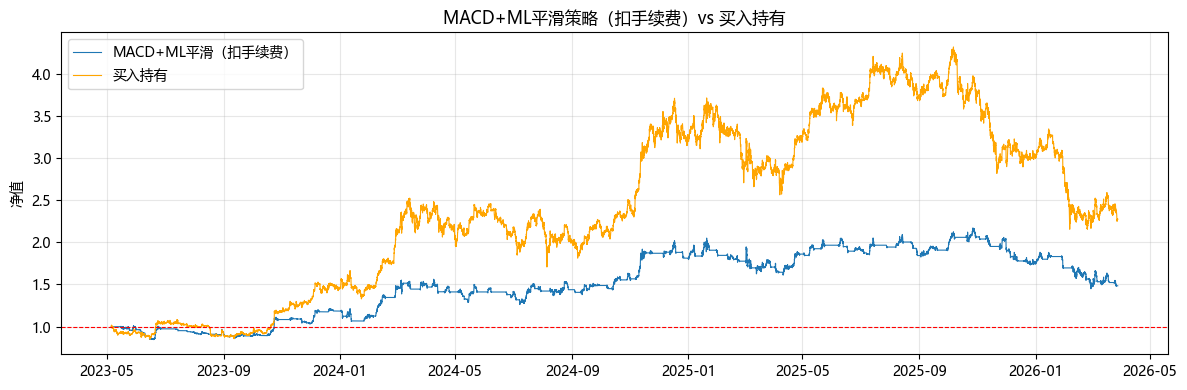

In [19]:
# 加持仓缓冲：信号连续N小时才切换
def smooth_signal(signal, window=12):
    # 用滚动均值平滑信号，减少频繁切换
    smoothed = signal.rolling(window).mean()
    result = pd.Series(0.0, index=signal.index)
    result[smoothed > 0.6] = 1.0
    result[smoothed < 0.3] = 0.0
    result[(smoothed >= 0.3) & (smoothed <= 0.6)] = 0.5
    return result

combined_smooth = smooth_signal(combined_ml, window=24)

trade_count2 = (combined_smooth.diff() != 0).sum()
years2 = len(combined_smooth) / 8760
print(f"平滑后交易次数：{trade_count2}")
print(f"平均每年交易：{trade_count2/years2:.0f}次")
print(f"总手续费：{trade_count2 * cost_per_trade:.2%}")

ret_s = close_1h[combined_smooth.index].pct_change().dropna()
sig_s = combined_smooth.shift(1).dropna()
c_s = ret_s.index.intersection(sig_s.index)
strat_ret_s = ret_s[c_s] * sig_s[c_s]

# 扣手续费
pv_smooth = [1.0]
holding = 0
for i, date in enumerate(c_s):
    if i == 0:
        holding = sig_s.loc[date]
        pv_smooth.append(pv_smooth[-1])
        continue
    dr = ret_s.loc[date] * holding
    new_holding = sig_s.loc[date]
    if new_holding != holding:
        dr -= cost_per_trade
    holding = new_holding
    pv_smooth.append(pv_smooth[-1] * (1 + dr))

pv_smooth = pd.Series(pv_smooth[1:], index=c_s)
bh_s = (1 + ret_s[c_s]).cumprod()

total_s = pv_smooth.iloc[-1] - 1
sharpe_s = strat_ret_s.mean() / strat_ret_s.std() * np.sqrt(8760)
dd_s = ((pv_smooth - pv_smooth.cummax()) / pv_smooth.cummax()).min()

print(f"\nMACD+ML平滑 累计收益：{total_s:.2%}")
print(f"MACD+ML平滑 Sharpe：{sharpe_s:.4f}")
print(f"MACD+ML平滑 最大回撤：{dd_s:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_smooth.index, pv_smooth, linewidth=0.8, label="MACD+ML平滑（扣手续费）")
plt.plot(bh_s.index, bh_s, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("MACD+ML平滑策略（扣手续费）vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()